<a href="https://colab.research.google.com/github/HassaanDeveloper/AI-ML-Internship-Tasks/blob/main/Task_2/AI_ML_Internship_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance --quiet

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
ticker = 'AAPL'
df = yf.download(ticker, start='2023-01-01', end='2025-01-01')

df = df.dropna()
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 Rows:")
print(df.head())

/tmp/ipykernel_1565/3012694427.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2023-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed

Dataset Shape: (502, 5)

First 5 Rows:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.982697  128.715393  122.097715  128.105746  112117500
2023-01-04  124.251190  126.512809  122.992553  124.772344   89113600
2023-01-05  122.933540  125.637646  122.677885  125.008327   80962700
2023-01-06  127.456764  128.115581  122.805707  123.907018   87754700
2023-01-09  127.977913  131.183516  127.722257  128.292580   70790800


In [ ]:
df = df.copy()
df.columns = df.columns.get_level_values(0)

df['Target'] = df['Close'].shift(-1)
df = df.dropna()

features = ['Open', 'High', 'Low', 'Volume']
X = df[features]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 400
Testing samples:  101


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("=== Linear Regression ===")
print(f"MAE:  {mean_absolute_error(y_test, lr_preds):.2f}")
print(f"R²:   {r2_score(y_test, lr_preds):.4f}")

print("\n=== Random Forest ===")
print(f"MAE:  {mean_absolute_error(y_test, rf_preds):.2f}")
print(f"R²:   {r2_score(y_test, rf_preds):.4f}")

=== Linear Regression ===
MAE:  2.47
R²:   0.9219

=== Random Forest ===
MAE:  5.70
R²:   0.2671


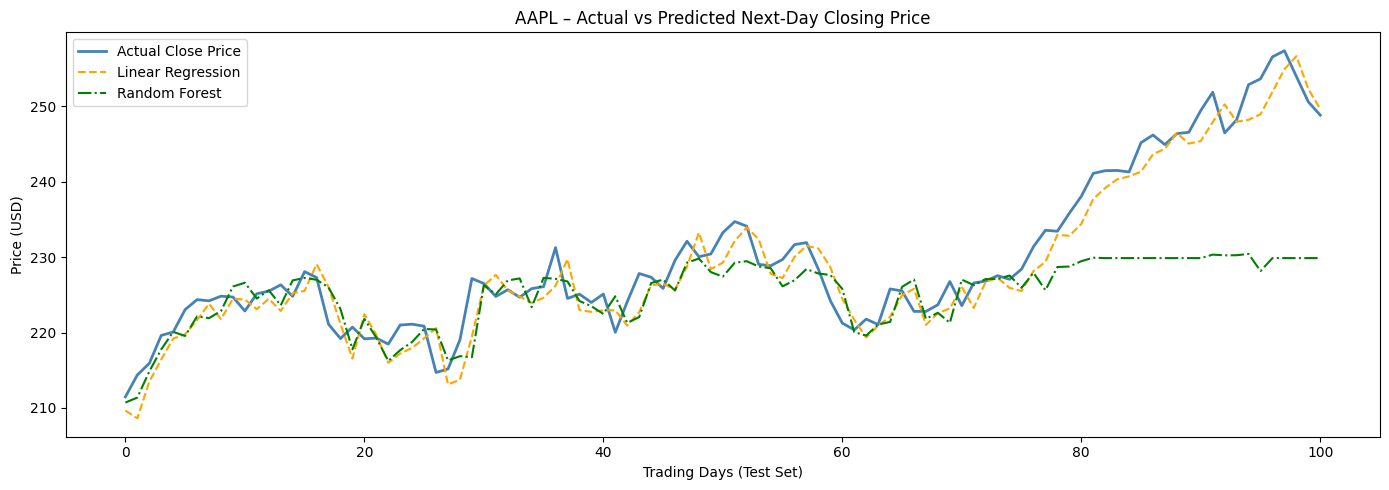

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(y_test.values, label='Actual Close Price', color='steelblue', linewidth=2)
plt.plot(lr_preds, label='Linear Regression', color='orange', linestyle='--', linewidth=1.5)
plt.plot(rf_preds, label='Random Forest', color='green', linestyle='-.', linewidth=1.5)

plt.title(f'{ticker} – Actual vs Predicted Next-Day Closing Price')
plt.xlabel('Trading Days (Test Set)')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()